<a href="https://colab.research.google.com/github/Robin-FIME/InteligenciaArtificial_y_RedesNeuronales_UANL_FIME/blob/main/ACTIVIDADES/AF6_Decision_Tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Actividad 6: Aprendizaje supervisado, árbol de decisión**
-**Grupo:** 004 -**Horario de clase:** Jueves N1 a N3
* **2066292**	Gabriel Alejandro Almanza Mata	**IMC**

* **2100051**	Alfredo René Robles Guzman	**IMC**

* **2177682**	Luis Mauricio Torres Mayorga **IMC**

* **2111623** Valeria Monserrat Rincón Vásquez **IMC**

* **1930458** Juan Carlos Torres Gonzales **IMC**



In [9]:
# Cargar librerías
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

In [10]:
# Cargar datos
cancer_data = load_breast_cancer()
X = pd.DataFrame(cancer_data.data, columns=cancer_data.feature_names)
y = cancer_data.target

print(f"Total de muestras: {X.shape[0]}, Características: {X.shape[1]}")

Total de muestras: 569, Características: 30


In [11]:
# Preprocesamiento de datos
# 80% entrenamiento (train) y 20% prueba (test)
train_data, test_data, train_labels, test_labels = train_test_split(X, y, test_size=0.20, random_state=42)

print(f"Datos de entrenamiento: {train_data.shape[0]}")
print(f"Datos de prueba: {test_data.shape[0]}")

Datos de entrenamiento: 455
Datos de prueba: 114


In [14]:
# Selección y entrenamiento del modelo
clf = DecisionTreeClassifier(random_state=42)
clf.fit(train_data, train_labels)

print("¡Modelo entrenado exitosamente!")

¡Modelo entrenado exitosamente!


Precisión (Accuracy): 0.9474

Reporte de Clasificación:
              precision    recall  f1-score   support

     Benigno       0.93      0.93      0.93        43
     Maligno       0.96      0.96      0.96        71

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



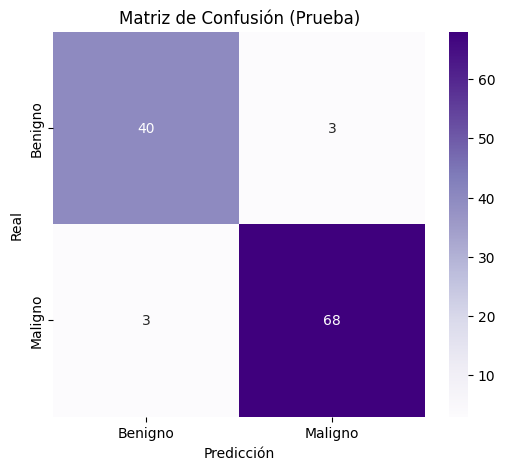

In [31]:
# Importamos seaborn para el diseño de la matriz
import seaborn as sns

# Prueba del modelo con el conjunto test_data
predicciones = clf.predict(test_data)

acc = accuracy_score(test_labels, predicciones)
print(f"Precisión (Accuracy): {acc:.4f}\n")

nombres_clases = ["Benigno", "Maligno"]

print("Reporte de Clasificación:")
print(classification_report(test_labels, predicciones, target_names=nombres_clases))

# Generar la Matriz de Confusión
cm = confusion_matrix(test_labels, predicciones)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=nombres_clases,
            yticklabels=nombres_clases)

plt.ylabel("Real")
plt.xlabel("Predicción")
plt.title("Matriz de Confusión (Prueba)")

plt.show()

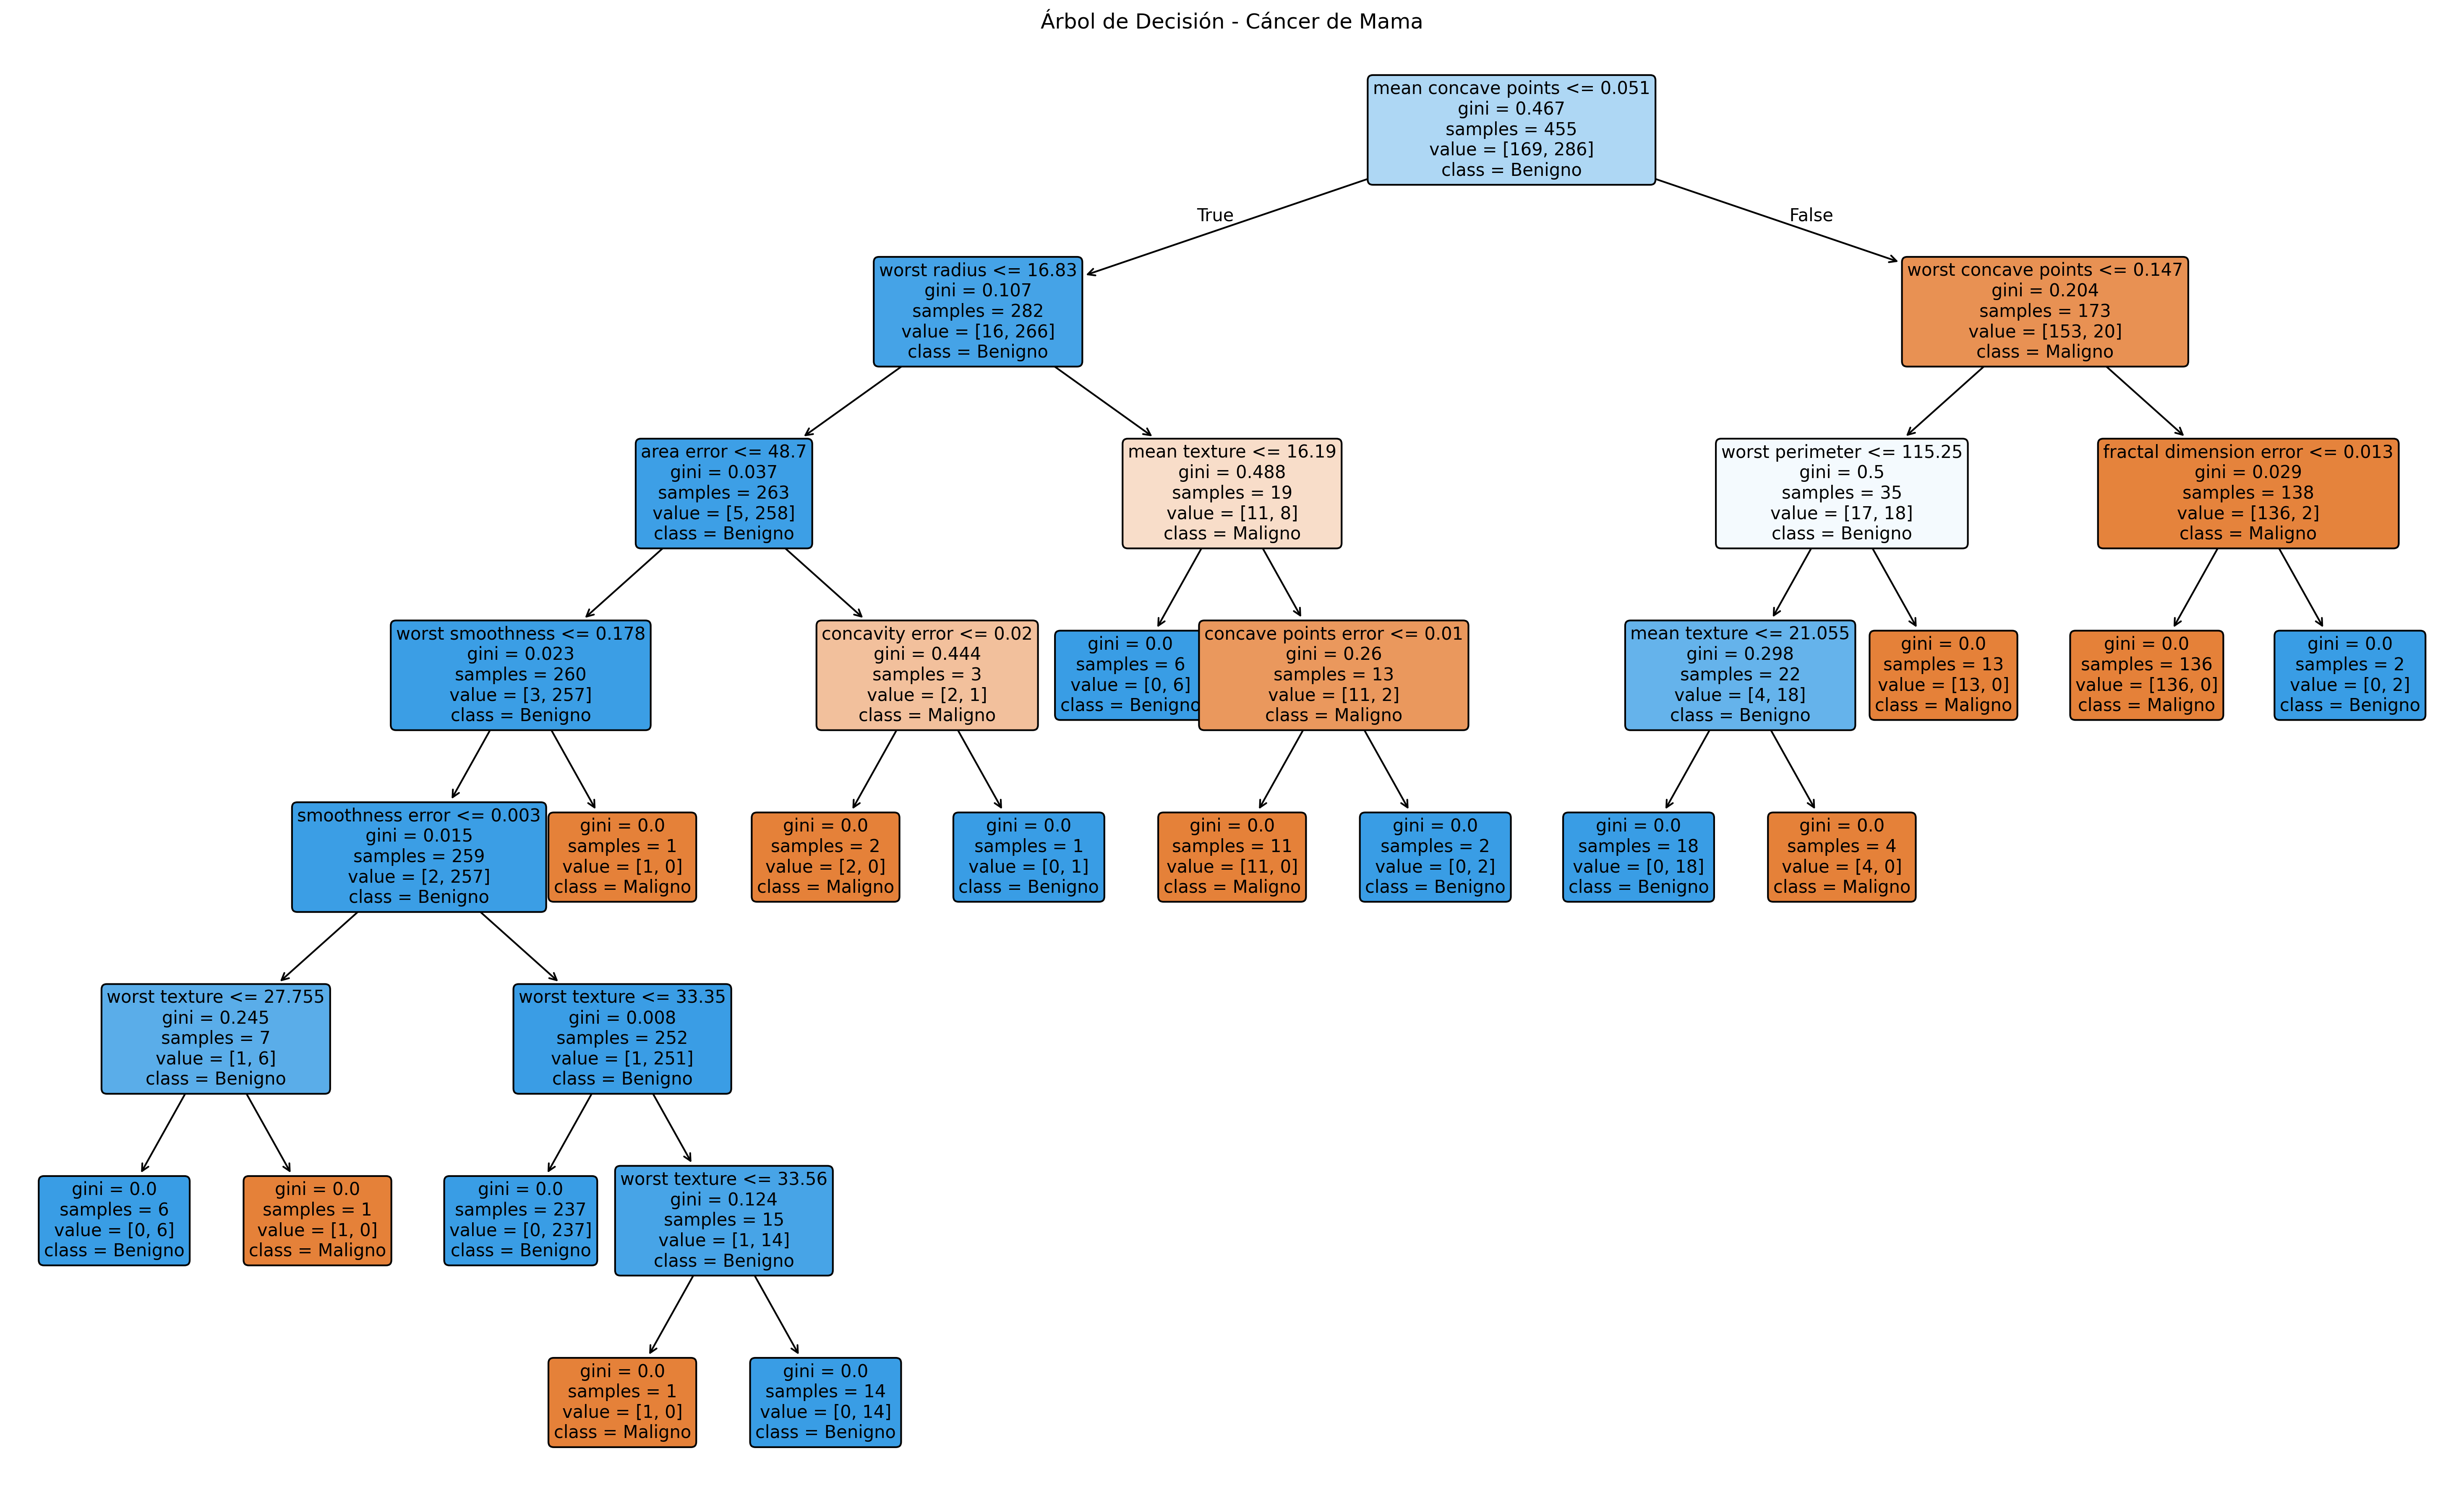

In [33]:
# Representación gráfica del árbol de decisión
plt.figure(figsize=(25, 15), dpi=300)

nombres_clases = ["Maligno", "Benigno"]

plot_tree(clf,
          feature_names=cancer_data.feature_names,
          class_names=nombres_clases,
          filled=True,
          rounded=True,
          fontsize=10)
plt.title("Árbol de Decisión - Cáncer de Mama")
plt.show()